In [2]:
from pathlib import Path
import sys
from dataclasses import dataclass

src_path = Path.cwd().parent / "src"
sys.path.insert(0, str(src_path))

from main import *
from scipy.linalg import expm
from scipy.optimize import nnls

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

In [102]:
# ============================================================================ #
# LATEX / STYLE SETTINGS
# ============================================================================ #

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 10
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10

plt.rcParams["text.latex.preamble"] = (
    r"\usepackage{amsmath} "
    r"\usepackage{amssymb} "
    r"\usepackage{mathptmx}"
)

plt.rcParams["axes.linewidth"] = 0.8
plt.rcParams["xtick.major.width"] = 0.8
plt.rcParams["ytick.major.width"] = 0.8
plt.rcParams["lines.linewidth"] = 1.2

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


# ============================================================================ #
# COLOURS, LABELS, LAYOUT TUNING
# ============================================================================ #

ORANGE = "#E97C4A"
GREEN  = "#4B8B3B"
BLUE   = "#3366AA"
BLACK  = "#000000"
LIGHT_GREY = "#BFBFBF"

# Labels set here
LABEL_ISS       = r"$\rho_{ss}$"
LABEL_BARE      = r"$\rho$"
LABEL_CD        = r"$\rho^{CD}$"
LABEL_RESIDUAL  = r"Residual"

# Layout fractions
LEFT_PANEL_RATIO  = 0.40
RIGHT_PANEL_RATIO = 0.60

# Golden ratio aspect for right-hand plots
PHI = (1 + np.sqrt(5)) / 2
RIGHT_BOX_ASPECT = 1.0 / PHI   # height / width ~ 0.618

# Visual emphasis
ISS_LINEWIDTH   = 1.35   # thinner than before
BARE_LINEWIDTH  = 1.5
CD_LINEWIDTH    = 1.5

ISS_ALPHA  = 1.0
BARE_ALPHA = 0.85
CD_ALPHA   = 0.85


In [86]:
# ============================================================================ #
# BLOCH SPHERE HELPER
# ============================================================================ #

def draw_bloch_sphere(
    ax,
    elev=20,
    azim=-55,
):
    """
    Draw a publication-style Bloch sphere.
    """

    u = np.linspace(0.0, 2.0 * np.pi, 100)
    v = np.linspace(0.0, np.pi, 50)

    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_surface(
        xs,
        ys,
        zs,
        color="0.85",
        alpha=0.075, #0.035
        linewidth=0,
        antialiased=True,
        shade=False,
        zorder=0,
    )

    theta = np.linspace(0.0, 2.0 * np.pi, 400)

    circle_style = dict(
        color=LIGHT_GREY,
        lw=0.55,
        alpha=0.9,
        zorder=1,
    )

    # Great circles
    ax.plot(np.cos(theta), np.sin(theta), np.zeros_like(theta), **circle_style)
    ax.plot(np.cos(theta), np.zeros_like(theta), np.sin(theta), **circle_style)
    ax.plot(np.zeros_like(theta), np.cos(theta), np.sin(theta), **circle_style)

    # Axes
    axis_lim = 1.08
    axis_style = dict(color="0.55", lw=0.55, zorder=1)

    ax.plot([-axis_lim, axis_lim], [0, 0], [0, 0], **axis_style)
    ax.plot([0, 0], [-axis_lim, axis_lim], [0, 0], **axis_style)
    ax.plot([0, 0], [0, 0], [-axis_lim, axis_lim], **axis_style)

    # Axis labels
    lp = 1.13
    ax.text(lp, 0, 0, r"$x$", ha="center", va="center")
    ax.text(0, lp, 0, r"$y$", ha="center", va="center")
    ax.text(0, 0, lp, r"$z$", ha="center", va="center")

    # Tight limits so sphere appears larger in its panel
    lim = 0.60
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)

    # Make the 3D object fill more of the allotted axes box
    try:
        ax.set_box_aspect((1, 1, 1), zoom=1.0)
    except TypeError:
        # Fallback for older matplotlib versions
        ax.set_box_aspect((1, 1, 1))

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_anchor("N")

    ax.set_axis_off()
    ax.view_init(elev=elev, azim=azim)


# ============================================================================ #
# RESIDUAL HELPER
# ============================================================================ #

def get_residual_from_agp_data(agp_data):
    candidate_keys = [
        "residual",
        "residuals",
        "residual_norm",
        "residual_norms",
        "relative_residual",
        "relative_residuals",
    ]

    for key in candidate_keys:
        if key in agp_data:
            residual = np.asarray(agp_data[key])

            if residual.ndim == 1:
                return residual

            return np.linalg.norm(
                residual.reshape(residual.shape[0], -1),
                axis=1,
            )

    raise KeyError(
        "Residual not found in agp_data.\n"
        f"Available keys are:\n{list(agp_data.keys())}"
    )


# ============================================================================ #
# SMALL HELPER FOR PANEL LABELS
# ============================================================================ #

def add_panel_label(ax, label, x=-0.18, y=1.02):
    """
    Put panel labels just outside the axes:
    slightly left of the y-axis and slightly above the top edge.
    """

    if hasattr(ax, "text2D"):
        # 3D axes
        ax.text2D(
            x,
            y,
            label,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
        )
    else:
        # 2D axes
        ax.text(
            x,
            y,
            label,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            clip_on=False,
        )

# ============================================================================ #
# PUBLICATION FIGURE
# ============================================================================ #

def plot_2LS_publication_figure(
    t,
    rho_ss,
    rho_bare,
    rho_cd,
    agp_data,
    filename="2LS_CD_APS.pdf",
):
    """
    Figure layout:

        left  (40%): Bloch sphere
        right (60%): residual on top, Frobenius error below
    """

    # ------------------------------------------------------------------------ #
    # Data
    # ------------------------------------------------------------------------ #

    b_ss = np.array([bloch(rho) for rho in rho_ss])
    b_bare = np.array([bloch(rho) for rho in rho_bare])
    b_cd = np.array([bloch(rho) for rho in rho_cd])

    error_bare = np.array([
        np.linalg.norm(rho - target, ord="fro")
        for rho, target in zip(rho_bare, rho_ss)
    ])

    error_cd = np.array([
        np.linalg.norm(rho - target, ord="fro")
        for rho, target in zip(rho_cd, rho_ss)
    ])

    residual = get_residual_from_agp_data(agp_data)
    residual_plot = np.maximum(np.abs(residual), 1e-15)

    # ------------------------------------------------------------------------ #
    # Figure geometry
    # ------------------------------------------------------------------------ #

    cm = 1.0 / 2.54
    fig_width_cm = 8.6
    fig_width = fig_width_cm * cm

    # Taller than before so the stacked right panels breathe a bit more
    fig_height = 0.5 * fig_width

    fig = plt.figure(
        figsize=(fig_width, fig_height),
        constrained_layout=True,
    )

    fig.get_layout_engine().set(
        h_pad=0.01,
        w_pad=0.02,
        hspace=0.02,
        wspace=0.02,
    )

    # 40 / 60 split
    outer = fig.add_gridspec(
        nrows=1,
        ncols=2,
        width_ratios=[LEFT_PANEL_RATIO, RIGHT_PANEL_RATIO],
        wspace=0.03,
    )

    ax_bloch = fig.add_subplot(
        outer[0, 0],
        projection="3d",
    )

    right = outer[0, 1].subgridspec(
        nrows=2,
        ncols=1,
        height_ratios=[1.0, 1.0],
        hspace=0.12,
    )

    ax_res = fig.add_subplot(right[0, 0])
    ax_err = fig.add_subplot(right[1, 0])

    ax_res.set_box_aspect(RIGHT_BOX_ASPECT)
    ax_err.set_box_aspect(RIGHT_BOX_ASPECT)

    # ------------------------------------------------------------------------ #
    # (a) Bloch sphere
    # ------------------------------------------------------------------------ #

    draw_bloch_sphere(ax_bloch, elev=20, azim=-120)

    # Plot bare and CD first, a little more transparent
    ax_bloch.plot(
        b_bare[:, 0], b_bare[:, 1], b_bare[:, 2],
        color=ORANGE,
        linewidth=BARE_LINEWIDTH,
        alpha=BARE_ALPHA,
        label=LABEL_BARE,
        zorder=4,
    )

    ax_bloch.plot(
        b_cd[:, 0], b_cd[:, 1], b_cd[:, 2],
        color=GREEN,
        linewidth=CD_LINEWIDTH,
        alpha=CD_ALPHA,
        label=LABEL_CD,
        zorder=5,
    )

    # Plot ISS last so it sits visually on top and is clearer
    ax_bloch.plot(
        b_ss[:, 0], b_ss[:, 1], b_ss[:, 2],
        color=BLACK,
        linestyle="--",
        linewidth=ISS_LINEWIDTH,
        alpha=ISS_ALPHA,
        label=LABEL_ISS,
        zorder=6,
    )

    # Markers
    ax_bloch.scatter(
        b_ss[0, 0], b_ss[0, 1], b_ss[0, 2],
        color=BLACK,
        s=10,
        depthshade=False,
        zorder=10,
    )

    ax_bloch.scatter(
        b_ss[-1, 0], b_ss[-1, 1], b_ss[-1, 2],
        facecolors="none",
        edgecolors=BLACK,
        s=16,
        linewidths=0.75,
        depthshade=False,
        zorder=10,
    )

    # Legend under Bloch sphere
    ax_bloch.legend(
        loc="lower center",
        bbox_to_anchor=(0.52, -0.2),
        ncol=3,
        frameon=False,
        handlelength=1.3,
        handletextpad=0.3,
        columnspacing=0.6,
        borderpad=0.0,
        labelspacing=0.0,
    )

    add_panel_label(ax_bloch, r"(a)")

    # ------------------------------------------------------------------------ #
    # (b) Residual
    # ------------------------------------------------------------------------ #

    ax_res.plot(
        t[:len(residual_plot)],
        residual_plot,
        color=BLUE,
        linewidth=1.2,
    )

    ax_res.set_yscale("log")
    ax_res.set_ylabel(r"Residual")
    ax_res.set_xlim(t[0], t[-1])
    
    ax_res.tick_params(
        axis="x",
        labelbottom=False,
    )

    ax_res.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    add_panel_label(ax_res, r"(b)")

    # ------------------------------------------------------------------------ #
    # (c) Frobenius tracking error
    # ------------------------------------------------------------------------ #

    ax_err.plot(
        t,
        error_bare,
        color=ORANGE,
        linewidth=1.4,
        label=LABEL_BARE,
    )

    ax_err.plot(
        t,
        error_cd,
        color=GREEN,
        linewidth=1.4,
        label=LABEL_CD,
    )

    ax_err.set_xlabel(r"Time, $t$")
    ax_err.set_ylabel(r"$\|\rho-\rho_{\mathrm{ss}}\|_{\mathrm{F}}$")
    ax_err.set_xlim(t[0], t[-1])

    ax_err.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    # Remove normal legend and directly label on right side
    ax_err.legend(
        loc="upper right",
        frameon=False,
        handlelength=1.0,
        handletextpad=0.25,
        labelspacing=0.0,
        borderpad=0.1,
    )

    add_panel_label(ax_err, r"(c)")

    # ------------------------------------------------------------------------ #
    # Save
    # ------------------------------------------------------------------------ #

    if filename is not None:
        plt.savefig(
            filename,
            dpi=600,
            bbox_inches="tight",
            pad_inches=0,
        )

    return fig


# ============================================================================ #
# MAIN EVOLUTION FUNCTION
# ============================================================================ #

def run_and_plot_2LS_case(
    title,
    model,
    s_of_t,
    sdot_of_t,
    times,
    hamiltonians,
    jump_operators,
    figure_filename="2LS_CD_APS.pdf",
):
    # Approximate CD
    t, traj_cd, rho_cd, rho_ss, agp_data = approx_CD_trajectory(
        model=model,
        s_of_t=s_of_t,
        times=times,
        hamiltonians=hamiltonians,
        jump_operators=jump_operators,
        dim=2,
        sdot_of_t=sdot_of_t,
        lam_unitary=1e-10,
        lam_dissipative=1e-10,
        plot_residual=False,
        residual_logscale=True,
    )

    # Bare evolution
    bare_model = LindbladModel2LS(
        lambda tt: model.H(s_of_t(tt)),
        lambda tt: model.jumps(s_of_t(tt)),
    )

    builder = LiouvillianBuilder(dim=2)

    traj_bare, rho_bare = evolve_density_matrices(
        bare_model,
        builder,
        rho_ss[0],
        t,
    )

    # Derived arrays
    b_ss = np.array([bloch(rho) for rho in rho_ss])
    b_bare = np.array([bloch(rho) for rho in rho_bare])
    b_cd = np.array([bloch(rho) for rho in rho_cd])

    error_bare = np.array([
        np.linalg.norm(rho - target, ord="fro")
        for rho, target in zip(rho_bare, rho_ss)
    ])

    error_cd = np.array([
        np.linalg.norm(rho - target, ord="fro")
        for rho, target in zip(rho_cd, rho_ss)
    ])

    fig = plot_2LS_publication_figure(
        t=t,
        rho_ss=rho_ss,
        rho_bare=rho_bare,
        rho_cd=rho_cd,
        agp_data=agp_data,
        filename=figure_filename,
    )

    return {
        "t": t,
        "rho_ss": rho_ss,
        "rho_bare": rho_bare,
        "rho_cd": rho_cd,
        "bloch_ss": b_ss,
        "bloch_bare": b_bare,
        "bloch_cd": b_cd,
        "error_bare": error_bare,
        "error_cd": error_cd,
        "agp_data": agp_data,
        "fig": fig,
    }


## 1. Non-rotating Bloch vector
The parameter-dependent Lindbladian is

$$
\mathcal{L}_s[\rho]
=
-i\left[\frac{B_z}{2}\sigma_z,\rho\right]
+
\kappa(1+s)\mathcal{D}[\sigma_-]\rho
+
\kappa(1-s)\mathcal{D}[\sigma_+]\rho,
$$

where

$$
\mathcal{D}[L]\rho
=
L\rho L^\dagger
-\frac{1}{2}\left\{L^\dagger L,\rho\right\}.
$$

Thus the downward and upward rates are

$$
\gamma_\downarrow(s)=\kappa(1+s),
\qquad
\gamma_\uparrow(s)=\kappa(1-s).
$$

With the convention
$\sigma_z=\operatorname{diag}(1,-1)$, the instantaneous steady state is

$$
\rho_{\mathrm{ss}}(s)
=
\frac{1}{2}\left(I-s\sigma_z\right),
$$

and therefore

$$
\langle \sigma_z\rangle_{\mathrm{ss}}=-s.
$$

2


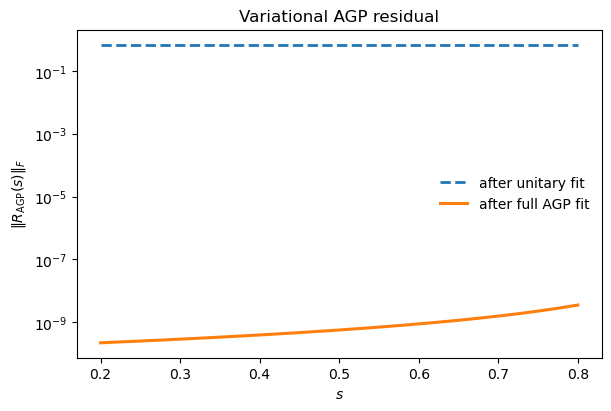

2


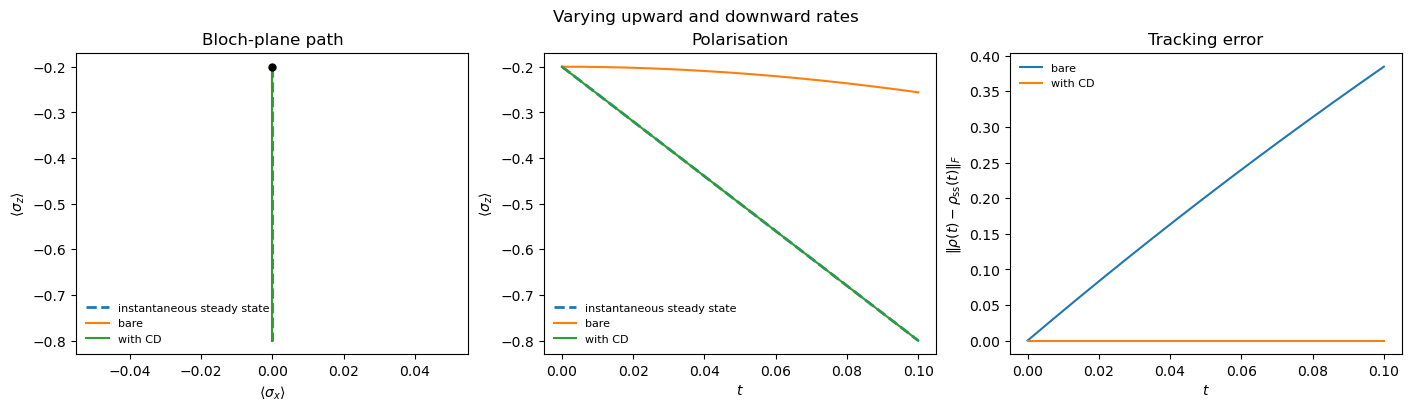

In [ ]:
# ============================================================
# Case 1: varying up/down rates
# ============================================================

kappa = 1.0
Bz = 1.0

s0 = 0.2
s1 = 0.8
tau = 0.1
nsteps = 301

times = np.linspace(0.0, tau, nsteps)

# Linear ramp gives a uniform parameter grid.
s_of_t = lambda t: s0 + (s1 - s0) * t / tau
sdot_of_t = lambda t: (s1 - s0) / tau


def H_case1(s):
    return 0.5 * Bz * Pauli.sz


def jumps_case1(s):
    return [
        Jump(Pauli.sm, kappa * (1.0 + s)),
        Jump(Pauli.sp, kappa * (1.0 - s)),
    ]


model_case1 = LindbladModel2LS(
    H_case1,
    jumps_case1,
)

results_case1 = run_and_plot_2LS_case(
    title="Varying upward and downward rates",
    model=model_case1,
    s_of_t=s_of_t,
    sdot_of_t=sdot_of_t,
    times=times,
    hamiltonians=[
        Pauli.sx,
        Pauli.sy,
    ],
    jump_operators=[
        Pauli.sm,
        Pauli.sp,
    ],
)

## 2. Rotation of Bloch vector
The parameter-dependent Lindbladian is

$$
\mathcal{L}_{B_x}[\rho]
=
-i\left[
\frac{1}{2}
\left(
B_z\sigma_z+B_x\sigma_x
\right),
\rho
\right]
+
\kappa\mathcal{D}[\sigma_-]\rho,
$$

where

$$
\mathcal{D}[L]\rho
=
L\rho L^\dagger
-\frac{1}{2}\left\{L^\dagger L,\rho\right\}.
$$

Here $B_z$ and $\kappa$ are constant, while $B_x$ is the
time-dependent control parameter,

$$
B_x=B_x(t).
$$


2


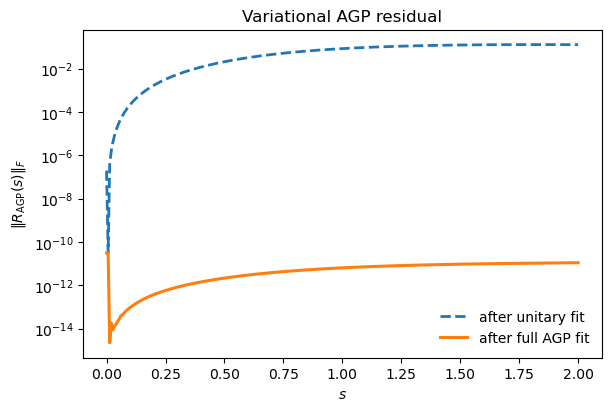

2


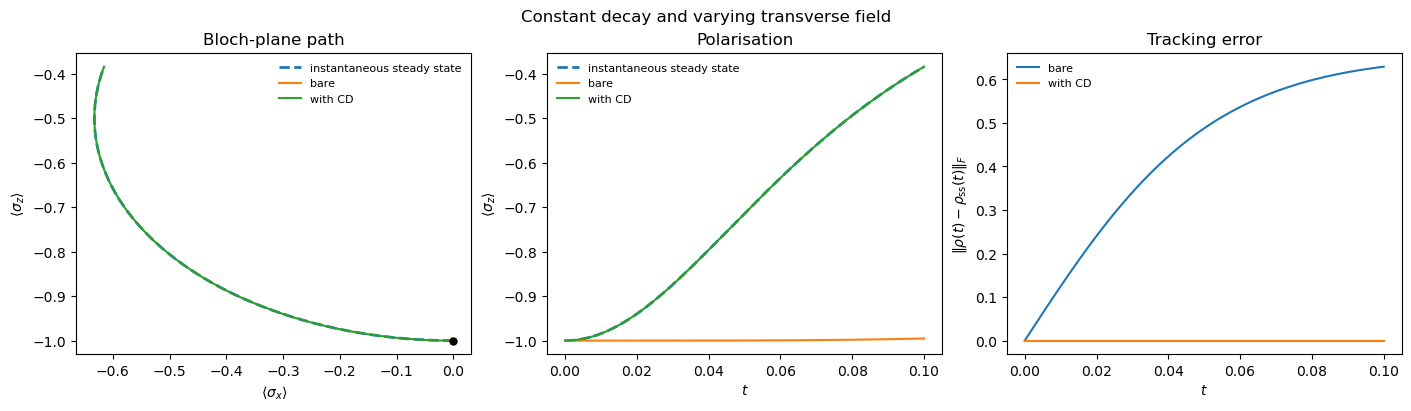

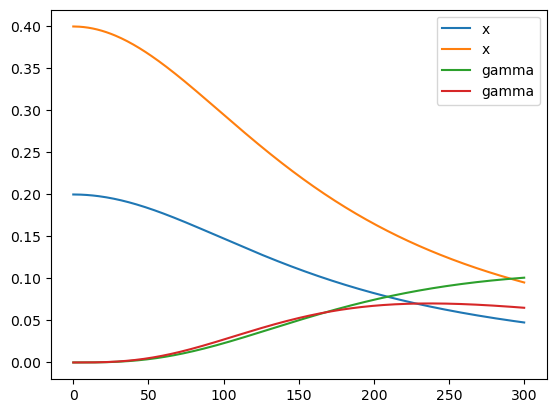

In [69]:
# ============================================================
# Case 2: constant down dissipator, varying Bx
# ============================================================

kappa = 1.0
Bz = 1.0

Bx0 = 0.0
Bx1 = 2.0
tau = 0.1
nsteps = 301

times = np.linspace(0.0, tau, nsteps)

Bx_of_t = lambda t: Bx0 + (Bx1 - Bx0) * t / tau
Bxdot_of_t = lambda t: (Bx1 - Bx0) / tau


def H_case2(Bx):
    return 0.5 * (
        Bz * Pauli.sz
        + Bx * Pauli.sx
    )


def jumps_case2(Bx):
    return [
        Jump(Pauli.sm, kappa),
    ]


model_case2 = LindbladModel2LS(
    H_case2,
    jumps_case2,
)

results_case2 = run_and_plot_2LS_case(
    title="Constant decay and varying transverse field",
    model=model_case2,
    s_of_t=Bx_of_t,
    sdot_of_t=Bxdot_of_t,
    times=times,
    hamiltonians=[ 
        Pauli.sx,
        Pauli.sy,
        #Pauli.sz,
    ],
    jump_operators=[
        #Pauli.sx,
        #Pauli.sy,
        Pauli.sz,
        #Pauli.sm,
        Pauli.sp,
        # Pauli.sy+1.j*Pauli.sz,
        # Pauli.sy-1.j*Pauli.sz,
        # Pauli.sz-1.j*Pauli.sx,
        # Pauli.sz+1.j*Pauli.sx,
    ]
)


plt.plot(results_case2["agp_data"]["x"], label="x")
plt.plot(results_case2["agp_data"]["gamma"], label="gamma")
plt.legend()
plt.show()

2
2


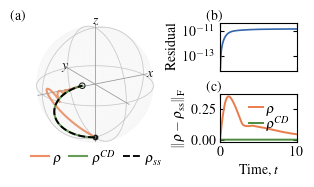

In [103]:
kappa = 1.0
Bz = 1.0

Bx0 = 0.0
Bx1 = 10.0

tau = 10.0
nsteps = 701

times = np.linspace(0.0, tau, nsteps)

Bx_of_t = lambda t: Bx0 + (Bx1 - Bx0) * t / tau
Bxdot_of_t = lambda t: (Bx1 - Bx0) / tau


def H_case2(Bx):
    return 0.5 * (
        Bz * Pauli.sz
        + Bx * Pauli.sx
    )


def jumps_case2(Bx):
    return [
        Jump(Pauli.sm, kappa),
    ]


model_case2 = LindbladModel2LS(
    H_case2,
    jumps_case2,
)

results_case2 = run_and_plot_2LS_case(
    title="Constant decay and varying transverse field",
    model=model_case2,
    s_of_t=Bx_of_t,
    sdot_of_t=Bxdot_of_t,
    times=times,
    hamiltonians=[
        Pauli.sx,
        Pauli.sy,
    ],
    jump_operators=[
        Pauli.sz,
        Pauli.sp,
    ],
    figure_filename="2LS_CD_APS.pdf",
)

Old functions (in case I need some functionality from them again)

In [ ]:



# # ============================================================
# # Minimal helper: run bare + CD dynamics and plot comparison
# # ============================================================

# def run_and_plot_2LS_case(
#     title,
#     model,
#     s_of_t,
#     sdot_of_t,
#     times,
#     hamiltonians,
#     jump_operators,
# ):
#     # Approximate-CD evolution
#     t, traj_cd, rho_cd, rho_ss, agp_data = approx_CD_trajectory(
#         model=model,
#         s_of_t=s_of_t,
#         times=times,
#         hamiltonians=hamiltonians,
#         jump_operators=jump_operators,
#         dim=2,
#         sdot_of_t=sdot_of_t,
#         lam_unitary=1e-10,
#         lam_dissipative=1e-10,
#         plot_residual=True,
#         residual_logscale=True,
#     )

#     # Bare time-dependent model L(s(t))
#     bare_model = LindbladModel2LS(
#         lambda tt: model.H(s_of_t(tt)),
#         lambda tt: model.jumps(s_of_t(tt)),
#     )

#     builder = LiouvillianBuilder(dim=2)

#     traj_bare, rho_bare = evolve_density_matrices(
#         bare_model,
#         builder,
#         rho_ss[0],
#         t,
#     )

#     # Bloch vectors
#     b_ss = np.array([bloch(rho) for rho in rho_ss])
#     b_bare = np.array([bloch(rho) for rho in rho_bare])
#     b_cd = np.array([bloch(rho) for rho in rho_cd])

#     # Full density-matrix tracking errors
#     error_bare = np.array([
#         np.linalg.norm(rho - target, ord="fro")
#         for rho, target in zip(rho_bare, rho_ss)
#     ])

#     error_cd = np.array([
#         np.linalg.norm(rho - target, ord="fro")
#         for rho, target in zip(rho_cd, rho_ss)
#     ])

#     # --------------------------------------------------------
#     # Plot
#     # --------------------------------------------------------
#     fig, ax = plt.subplots(
#         1,
#         3,
#         figsize=(14, 4),
#         constrained_layout=True,
#     )

#     # Bloch-plane trajectory
#     ax[0].plot(
#         b_ss[:, 0],
#         b_ss[:, 2],
#         "--",
#         linewidth=2,
#         label="instantaneous steady state",
#     )
#     ax[0].plot(
#         b_bare[:, 0],
#         b_bare[:, 2],
#         label="bare",
#     )
#     ax[0].plot(
#         b_cd[:, 0],
#         b_cd[:, 2],
#         label="with CD",
#     )
#     ax[0].scatter(
#         b_ss[0, 0],
#         b_ss[0, 2],
#         color="black",
#         s=25,
#         zorder=5,
#     )
#     ax[0].set_xlabel(r"$\langle\sigma_x\rangle$")
#     ax[0].set_ylabel(r"$\langle\sigma_z\rangle$")
#     ax[0].set_title("Bloch-plane path")
#     ax[0].legend(frameon=False, fontsize=8)

#     # z polarisation
#     ax[1].plot(
#         t,
#         b_ss[:, 2],
#         "--",
#         linewidth=2,
#         label="instantaneous steady state",
#     )
#     ax[1].plot(t, b_bare[:, 2], label="bare")
#     ax[1].plot(t, b_cd[:, 2], label="with CD")
#     ax[1].set_xlabel(r"$t$")
#     ax[1].set_ylabel(r"$\langle\sigma_z\rangle$")
#     ax[1].set_title("Polarisation")
#     ax[1].legend(frameon=False, fontsize=8)

#     # Tracking error
#     ax[2].plot(t, error_bare, label="bare")
#     ax[2].plot(t, error_cd, label="with CD")
#     ax[2].set_xlabel(r"$t$")
#     ax[2].set_ylabel(
#         r"$\|\rho(t)-\rho_{\rm ss}(t)\|_F$"
#     )
#     ax[2].set_title("Tracking error")
#     ax[2].legend(frameon=False, fontsize=8)

#     fig.suptitle(title)
#     plt.show()

#     return {
#         "t": t,
#         "rho_ss": rho_ss,
#         "rho_bare": rho_bare,
#         "rho_cd": rho_cd,
#         "bloch_ss": b_ss,
#         "bloch_bare": b_bare,
#         "bloch_cd": b_cd,
#         "error_bare": error_bare,
#         "error_cd": error_cd,
#         "agp_data": agp_data,
#     }